In [4]:
from my_samples import ggF_samples, vbf_kappa_lambda_samples

In [12]:
import uproot
import numpy as np
import matplotlib.pyplot as plt


def photon_btag(files, btag = None):
    
    dR_values = []
    weights = []
    
    for filepath in files:
        with uproot.open(filepath) as file:
            tree = file["AnalysisMiniTree"]
            
            branches = ["bbyy_LargeRJet1_eta_NOSYS", "bbyy_LargeRJet1_phi_NOSYS", "bbyy_Photon1_eta_NOSYS", 
                        
                        "bbyy_Photon1_phi_NOSYS", "generatorWeight_NOSYS"]
            
            if btag:
                branches.append(btag)
                
            arrays = tree.arrays(branches, library = 'np')
            
            
            for i in range(len(arrays["generatorWeight_NOSYS"])):
                
                if len(arrays["bbyy_LargeRJet1_phi_NOSYS"]) <1 : continue
                if len(arrays["bbyy_Photon1_eta_NOSYS"]) < 1 : continue 
                
                jet_eta = arrays["bbyy_LargeRJet1_eta_NOSYS"][i]
                jet_phi = arrays["bbyy_LargeRJet1_phi_NOSYS"][i]
                
                photon_eta = arrays["bbyy_Photon1_eta_NOSYS"][i]
                photon_phi = arrays["bbyy_Photon1_phi_NOSYS"][i]
                
                if btag:
                    
                    if arrays[btag][i] != 1:
                        continue
                
                
                deta = jet_eta - photon_eta
                dphi = jet_phi - photon_phi
                dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
                
                dR = np.sqrt(deta**2 + dphi**2)
                
                dR_values.append(dR)
                weights.append(arrays["generatorWeight_NOSYS"][i])
                               
                               
    return dR_values, weights  

def plot_overlap_effect(files, title, save_name=None):
    
    working_points = {
        "No b-tagging": None,
        "WP 0.60% QCD Eff": "bbyy_LargeRJet1_Pass_GN3XPV01_hbb_FlatMassQCDEff_0p6_NOSYS",
        "WP 0.40% QCD Eff": "bbyy_LargeRJet1_Pass_GN3XPV01_hbb_FlatMassQCDEff_0p4_NOSYS",
        "WP 0.25% QCD Eff": "bbyy_LargeRJet1_Pass_GN3XPV01_hbb_FlatMassQCDEff_0p25_NOSYS",
        "WP 0.15% QCD Eff": "bbyy_LargeRJet1_Pass_GN3XPV01_hbb_FlatMassQCDEff_0p15_NOSYS",
        "WP 0.08% QCD Eff (Strictest)": "bbyy_LargeRJet1_Pass_GN3XPV01_hbb_FlatMassQCDEff_0p08_NOSYS"
    }

    plt.figure(figsize=(10, 6)) 

    for label_name, branch_name in working_points.items():
        
        dR_vals, w_vals = photon_btag(files, btag=branch_name)
        
        if len(dR_vals) > 0:
            plt.hist(dR_vals, bins=60, range=(0, 6), weights=w_vals,
                     histtype='step', linewidth=2, label=label_name)
            
    plt.xlabel("ΔR (Large-R Jet1, Photon1)")
    plt.ylabel("Weighted Events")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    if save_name:
        plt.savefig(save_name, dpi=300, bbox_inches='tight')
        print(f"Plot saved as: {save_name}")
        
    plt.show()

Plot saved as: overlap_ggF_SM.png


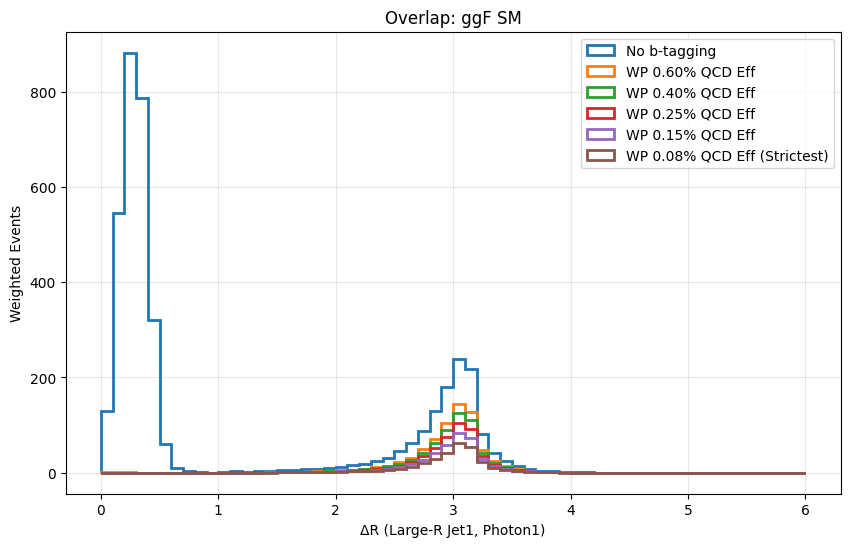

Plot saved as: overlap_VBF_SM.png


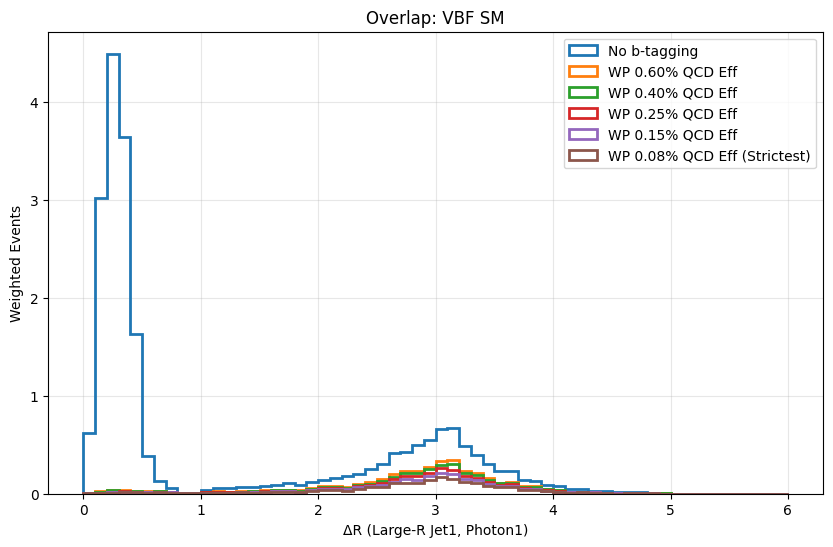

Plot saved as: overlap_BSM_kl10.png


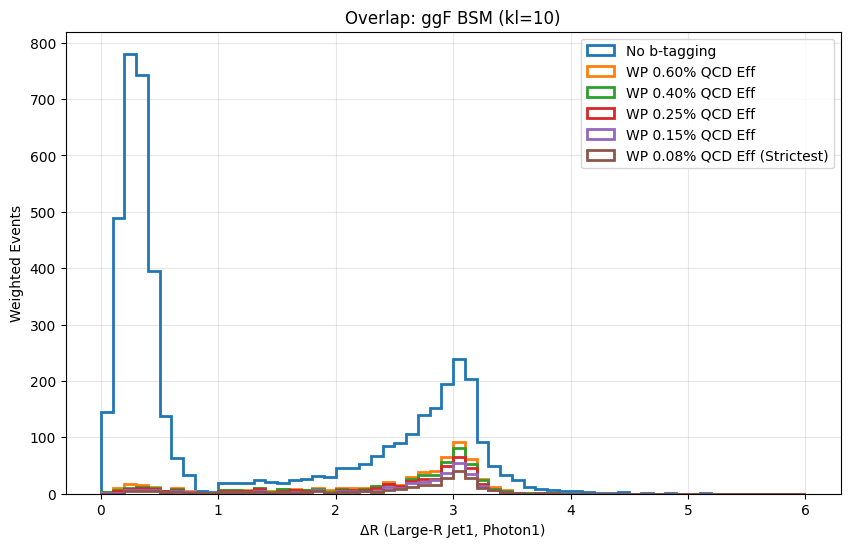

In [13]:
plot_overlap_effect(ggF_samples["ggF SM"], title="Overlap: ggF SM", save_name="overlap_ggF_SM.png")

plot_overlap_effect(vbf_kappa_lambda_samples["VBF SM"], title="Overlap: VBF SM", save_name="overlap_VBF_SM.png")

plot_overlap_effect(ggF_samples["ggF BSM (kl = 10)"], title="Overlap: ggF BSM (kl=10)", save_name="overlap_BSM_kl10.png")

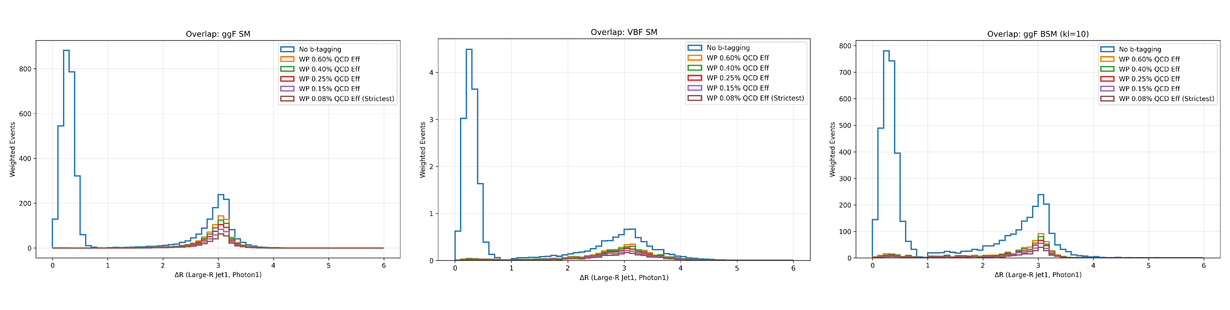

In [14]:
from IPython.display import Image
Image("overlap_photons.png")